<a href="https://colab.research.google.com/github/dastudillo1/AquaLimpia/blob/main/AquaLimpia_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto AquaLimpia S.A.

**Asignatura:** Ciencia de Datos  
**Semana:** 8  

## Objetivo
Analizar el comportamiento de las plantas de tratamiento de aguas residuales para identificar patrones de incumplimiento normativo, evaluar la eficiencia del proceso y generar información útil para distintas áreas de la empresa.

## Preguntas de investigación
1. ¿Qué planta presenta mayor DBO de salida promedio?
2. ¿Qué porcentaje de registros cumple la norma ambiental?
3. ¿Cómo evoluciona el DBO de salida en el tiempo?
4. ¿Existe relación entre el caudal de entrada y el DBO de salida?

## Trabajo colaborativo
El proyecto utiliza dos archivos externos compartidos:
-
-

Estos módulos permiten reutilizar funciones dentro del notebook principal.

## Metodología
- Carga del dataset.
- Evaluación de calidad de datos.
- Creación de variables derivadas.
- Uso de funciones externas compartidas.
- Construcción de dashboard 2x2.
- Exportación de reportes para dos áreas.


In [41]:
# ============================================================
# PROYECTO AQUALIMPIA S.A.
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ruta donde están los archivos de funciones compartidas
ruta_funciones = "/content/drive/MyDrive/Unidad3"

sys.path.insert(0, ruta_funciones)

print("Archivos encontrados:")
print(os.listdir(ruta_funciones))

Mounted at /content/drive
Archivos encontrados:
['dataset_set_A_aguas_residuales.xlsx', 'funciones_estadisticas.py', 'funciones_reportes.py', 'AquaLimpia_analisis.ipynb', '__pycache__']


In [42]:
from funciones_estadisticas import calcular_indicadores, evaluar_calidad_datos
from funciones_reportes import crear_reporte_operaciones, crear_reporte_gestion_ambiental

print("Funciones importadas correctamente")

Funciones importadas correctamente


## 1. Cargar Dataset


In [43]:
# ============================================================
# 1. CARGAR DATASET
# ============================================================

df = pd.read_excel("/content/drive/MyDrive/Unidad3/dataset_set_A_aguas_residuales.xlsx")

print("Primeras filas del dataset:")
display(df.head())
print("Filas:", len(df), "| Columnas:", len(df.columns))

Primeras filas del dataset:


,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0


Filas: 200 | Columnas: 10


## 2. Revisar Estructura del Dataset


In [44]:
# ============================================================
# 2. REVISAR ESTRUCTURA DEL DATASET
# ============================================================

print("Información general:")
df.info()

print("Estadísticas descriptivas:")
display(df.describe())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha_registro        200 non-null    object 
 1   planta                200 non-null    object 
 2   caudal_entrada_m3_d   200 non-null    int64  
 3   DBO_entrada_mg_L      200 non-null    int64  
 4   SST_entrada_mg_L      200 non-null    int64  
 5   pH_entrada            200 non-null    float64
 6   energia_aeracion_kWh  200 non-null    float64
 7   lodos_generados_kg_d  200 non-null    float64
 8   DBO_salida_mg_L       200 non-null    float64
 9   cumplimiento_norma    200 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 15.8+ KB
Estadísticas descriptivas:


,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.00000
mean,5059.285000,280.145000,232.670000,7.16240,1256.394500,428.795500,36.177500,0.22500
std,1410.971334,75.566497,64.289398,0.42381,420.146335,144.744253,13.259427,0.41863
min,1500.000000,90.000000,70.000000,6.18000,279.700000,113.700000,10.200000,0.00000
25%,4193.750000,223.000000,192.500000,6.84750,950.650000,321.175000,26.075000,0.00000
50%,5092.500000,284.000000,233.500000,7.14000,1212.850000,429.700000,35.150000,0.00000
75%,6037.750000,333.250000,277.500000,7.45250,1516.750000,524.825000,45.825000,0.00000
max,9205.000000,481.000000,391.000000,8.27000,2434.000000,971.700000,79.000000,1.00000


## 3. Evaluar Calidad de Datos


In [45]:
# ============================================================
# 3. EVALUAR CALIDAD DE DATOS
# ============================================================

calidad = evaluar_calidad_datos(df)

print("Valores nulos por columna:")
print(calidad["valores_nulos"])

print("Registros duplicados:", calidad["duplicados"])

print("Tipos de datos:")
print(calidad["tipos_datos"])

Valores nulos por columna:
fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
dtype: int64
Registros duplicados: 0
Tipos de datos:
fecha_registro           object
planta                   object
caudal_entrada_m3_d       int64
DBO_entrada_mg_L          int64
SST_entrada_mg_L          int64
pH_entrada              float64
energia_aeracion_kWh    float64
lodos_generados_kg_d    float64
DBO_salida_mg_L         float64
cumplimiento_norma        int64
dtype: object


## 4. Crear Variables Derivadas


In [46]:
# ============================================================
# 4. CREAR VARIABLES DERIVADAS
# ============================================================

# Eficiencia de tratamiento: porcentaje de DBO eliminado
df["eficiencia_tratamiento"] = (
    (df["DBO_entrada_mg_L"] - df["DBO_salida_mg_L"])
    / df["DBO_entrada_mg_L"]
) * 100

# Clasificación de alerta operativa según cumplimiento normativo
df["alerta_operativa"] = np.where(
    df["cumplimiento_norma"] == 0,
    "Incumplimiento",
    "Cumple"
)

print("Dataset con nuevas variables:")
display(df[["planta", "DBO_salida_mg_L", "eficiencia_tratamiento", "alerta_operativa"]].head())

Dataset con nuevas variables:


,planta,DBO_salida_mg_L,eficiencia_tratamiento,alerta_operativa
0,Planta Sur,40.0,85.239852,Incumplimiento
1,Planta Sur,26.8,91.677019,Cumple
2,Planta Norte,45.2,85.786164,Incumplimiento
3,Planta Centro,38.0,82.407407,Incumplimiento
4,Planta Centro,32.1,90.153374,Incumplimiento


## 5. Calcular Indicadores Estadísticos


In [47]:
# ============================================================
# 5. CALCULAR INDICADORES ESTADÍSTICOS
# ============================================================

# Función externa que usa NumPy, SciPy y Joblib
indicadores = calcular_indicadores(
    df["DBO_salida_mg_L"],
    "indicadores_DBO_salida.joblib"
)

print("Indicadores estadísticos de DBO de salida:")
print(indicadores)

Indicadores estadísticos de DBO de salida:
{'media': 36.1775, 'desviacion_estandar': 13.259427053191038, 'ic95': (34.32862691277957, 38.026373087220435)}


In [48]:
# Genera el Excel para Operaciones
reporte_operaciones = crear_reporte_operaciones(
    df,
    "reporte_operaciones_aqualimpia.xlsx"
)

# Genera el Excel para Gestión Ambiental
reporte_ambiental = crear_reporte_gestion_ambiental(
    df,
    "reporte_gestion_ambiental_aqualimpia.xlsx"
)

print("Reportes exportados correctamente")

Reportes exportados correctamente


## 6. Responder Preguntas de Investigación


In [49]:
# ============================================================
# 6. RESPONDER PREGUNTAS DE INVESTIGACIÓN
# ============================================================

# Pregunta 1: ¿Qué planta tiene mayor DBO de salida promedio?
dbo_planta = (
    df.groupby("planta")["DBO_salida_mg_L"]
    .mean()
    .sort_values(ascending=False)
)

# Pregunta 2: ¿Qué porcentaje de registros cumple la norma?
cumplimiento = df["alerta_operativa"].value_counts()

# Pregunta 3: ¿Cómo evoluciona el DBO de salida en el tiempo?
df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])
dbo_fecha = (
    df.groupby("fecha_registro")["DBO_salida_mg_L"]
    .mean()
    .sort_index()
)

# Pregunta 4: ¿Existe relación entre caudal de entrada y DBO de salida?
caudal = df["caudal_entrada_m3_d"]
dbo_salida = df["DBO_salida_mg_L"]

print("Plantas con mayor DBO de salida:")
display(dbo_planta)

print("Cumplimiento normativo:")
display(cumplimiento)

Plantas con mayor DBO de salida:


,DBO_salida_mg_L
planta,
Planta Norte,36.560563
Planta Sur,36.057407
Planta Centro,35.901333


Cumplimiento normativo:


,count
alerta_operativa,
Incumplimiento,155
Cumple,45


## 7. Dashboard 2x2


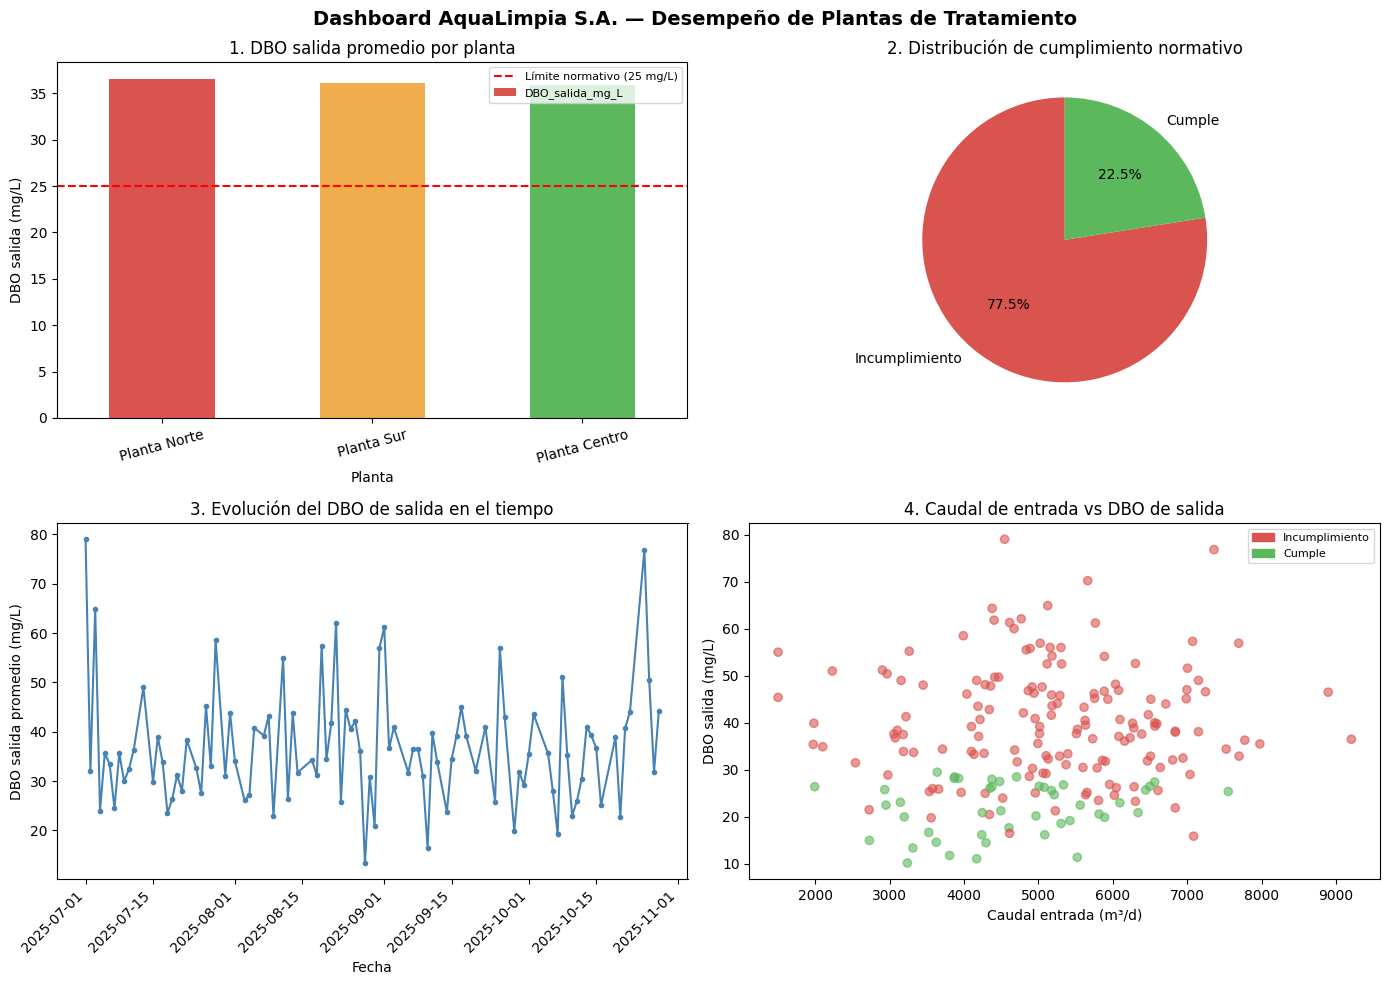

Dashboard guardado correctamente


In [50]:
# ============================================================
# 7. DASHBOARD 2X2
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dashboard AquaLimpia S.A. — Desempeño de Plantas de Tratamiento",
             fontsize=14, fontweight="bold")

# Gráfico 1: Barras — DBO salida promedio por planta
dbo_planta.plot(kind="bar", ax=axes[0,0], color=["#d9534f","#f0ad4e","#5cb85c"])
axes[0,0].set_title("1. DBO salida promedio por planta")
axes[0,0].set_xlabel("Planta")
axes[0,0].set_ylabel("DBO salida (mg/L)")
axes[0,0].tick_params(axis="x", rotation=15)
axes[0,0].axhline(y=25, color="red", linestyle="--", label="Límite normativo (25 mg/L)")
axes[0,0].legend(fontsize=8)

# Gráfico 2: Circular — Distribución de cumplimiento normativo
cumplimiento.plot(kind="pie", ax=axes[0,1], autopct="%1.1f%%",
                  startangle=90, colors=["#d9534f","#5cb85c"])
axes[0,1].set_title("2. Distribución de cumplimiento normativo")
axes[0,1].set_ylabel("")

# Gráfico 3: Línea — Evolución del DBO de salida en el tiempo
dbo_fecha.plot(kind="line", ax=axes[1,0], marker="o", markersize=3, color="steelblue")
axes[1,0].set_title("3. Evolución del DBO de salida en el tiempo")
axes[1,0].set_xlabel("Fecha")
axes[1,0].set_ylabel("DBO salida promedio (mg/L)")
axes[1,0].tick_params(axis="x", rotation=45)

# Gráfico 4: Dispersión — Caudal de entrada vs DBO de salida
colores = ["#d9534f" if v == "Incumplimiento" else "#5cb85c" for v in df["alerta_operativa"]]
axes[1,1].scatter(caudal, dbo_salida, c=colores, alpha=0.6)
axes[1,1].set_title("4. Caudal de entrada vs DBO de salida")
axes[1,1].set_xlabel("Caudal entrada (m³/d)")
axes[1,1].set_ylabel("DBO salida (mg/L)")

from matplotlib.patches import Patch
leyenda = [Patch(color="#d9534f", label="Incumplimiento"),
           Patch(color="#5cb85c", label="Cumple")]
axes[1,1].legend(handles=leyenda, fontsize=8)

plt.tight_layout()
plt.savefig("dashboard_aqualimpia_2x2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard guardado correctamente")

## 8. Interpretación de Resultados


In [51]:
# ============================================================
# 8. INTERPRETACIÓN DE RESULTADOS
# ============================================================

planta_critica = dbo_planta.index[0]
valor_critico = dbo_planta.iloc[0]
pct_incumplimiento = (cumplimiento.get("Incumplimiento", 0) / len(df)) * 100

print("Interpretación de resultados:")
print(f"- La planta con mayor DBO de salida promedio es {planta_critica} con {valor_critico:.1f} mg/L.")
print(f"- El {pct_incumplimiento:.1f}% de los registros presenta incumplimiento normativo.")
print("- La evolución temporal permite identificar periodos críticos de mayor contaminación.")
print("- El gráfico de dispersión permite evaluar si el caudal de entrada influye en la calidad del efluente.")

Interpretación de resultados:
- La planta con mayor DBO de salida promedio es Planta Norte con 36.6 mg/L.
- El 77.5% de los registros presenta incumplimiento normativo.
- La evolución temporal permite identificar periodos críticos de mayor contaminación.
- El gráfico de dispersión permite evaluar si el caudal de entrada influye en la calidad del efluente.


## 9. Decisiones Recomendadas


In [52]:
# ============================================================
# 9. DECISIONES RECOMENDADAS
# ============================================================

print("Decisiones recomendadas:")
print("- Priorizar revisión de la Planta Norte por presentar el mayor DBO de salida promedio.")
print("- Investigar las causas del 77.5% de incumplimiento normativo en el conjunto de plantas.")
print("- Monitorear los periodos de mayor DBO para planificar intervenciones preventivas.")
print("- Evaluar si el caudal de entrada es un factor determinante en los incumplimientos.")
print("- Usar los reportes exportados para apoyar decisiones de operaciones y gestión ambiental.")

Decisiones recomendadas:
- Priorizar revisión de la Planta Norte por presentar el mayor DBO de salida promedio.
- Investigar las causas del 77.5% de incumplimiento normativo en el conjunto de plantas.
- Monitorear los periodos de mayor DBO para planificar intervenciones preventivas.
- Evaluar si el caudal de entrada es un factor determinante en los incumplimientos.
- Usar los reportes exportados para apoyar decisiones de operaciones y gestión ambiental.


## Reflexión Ética

El análisis debe utilizarse para mejorar el proceso de tratamiento sin generar decisiones perjudiciales para comunidades específicas. Los resultados deben interpretarse considerando las limitaciones del dataset y el contexto operacional de cada planta. La comunicación de los incumplimientos debe ser equilibrada, presentando tanto los resultados críticos como las acciones correctivas disponibles, especialmente al reportar ante organismos fiscalizadores.
